# Unit 3 code companion: Linear Regression

Fitting a line, reading a slope with its units and its uncertainty, checking the residuals, putting a category into a model, and watching a coefficient change when another variable joins it.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
print(cars.shape); cars.head()

(392, 9)


,mpg,cylinder,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,American,buick
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth
3,16.0,8,304.0,150,3433,12.0,70,American,amc
4,17.0,8,302.0,140,3449,10.5,70,American,ford


## 1. A first fit, read out loud



In [2]:
fit = smf.ols("mpg ~ weight", data=cars).fit()
print(fit.summary().tables[1])

b1 = fit.params["weight"]
lo, hi = fit.conf_int().loc["weight"]
print(f"\nSlope      : {b1:.5f} mpg per pound")
print(f"Per 1000 lb: {1000*b1:.2f} mpg, 95% interval {1000*lo:.2f} to {1000*hi:.2f}")
print(f"Weight runs from {cars.weight.min():.0f} to {cars.weight.max():.0f} lb in this data")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.000      44.646      47.787
weight        -0.0076      0.000    -29.645      0.000      -0.008      -0.007

Slope      : -0.00765 mpg per pound
Per 1000 lb: -7.65 mpg, 95% interval -8.15 to -7.14
Weight runs from 1613 to 5140 lb in this data


The raw slope, $-0.0076$, looks like nothing. Per 1,000 pounds it is $-7.6$ mpg, which is large. Same number, same model. The units decide whether anyone understands you.

## 2. What least squares actually minimizes

Try a grid of candidate slopes and watch the sum of squared residuals bottom out at exactly the fitted value.

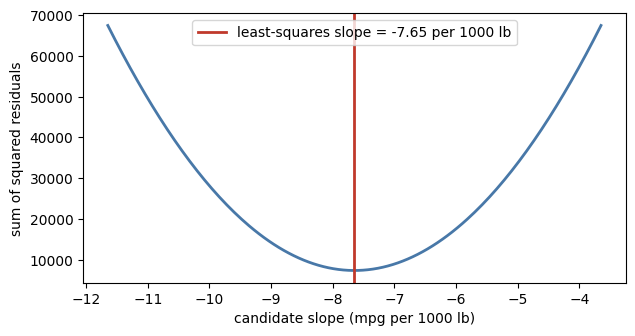

In [3]:
b0 = fit.params["Intercept"]
slopes = np.linspace(b1 - 0.004, b1 + 0.004, 200)
sse = [((cars.mpg - (b0 + s*cars.weight))**2).sum() for s in slopes]

plt.plot(slopes*1000, sse, color="#4878a8", lw=2)
plt.axvline(b1*1000, color="#c0392b", lw=2, label=f"least-squares slope = {b1*1000:.2f} per 1000 lb")
plt.xlabel("candidate slope (mpg per 1000 lb)"); plt.ylabel("sum of squared residuals")
plt.legend(); plt.show()

## 3. A slope is an estimate, so it wobbles

Here we know the truth because we made it up. Simulate the same study many times and the spread of the slopes is what the standard error is estimating.

true slope                      : 1.500
one study's estimate            : 1.771
that study's reported SE         : 0.142
SD of 1000 estimates (the truth) : 0.144


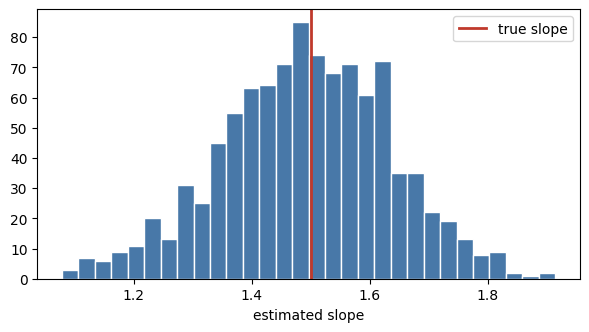

In [4]:
def one_study(n=200, true_slope=1.5):
    x = rng.normal(0, 1, n)
    y = 3 + true_slope*x + rng.normal(0, 2, n)
    return smf.ols("y ~ x", data=pd.DataFrame({"x": x, "y": y})).fit()

one = one_study()
many = np.array([one_study().params["x"] for _ in range(1000)])

print(f"true slope                      : 1.500")
print(f"one study's estimate            : {one.params['x']:.3f}")
print(f"that study's reported SE         : {one.bse['x']:.3f}")
print(f"SD of 1000 estimates (the truth) : {many.std():.3f}")
plt.hist(many, bins=30, color="#4878a8", edgecolor="white")
plt.axvline(1.5, color="#c0392b", lw=2, label="true slope")
plt.xlabel("estimated slope"); plt.legend(); plt.show()

The standard error printed by a single fit is an estimate of that spread, computed without ever rerunning the study. The $t$-statistic is the same ratio as in Unit 1: the estimate divided by its standard error.

## 4. Look at what the model missed

Residuals against fitted values. A shapeless cloud is what you want.

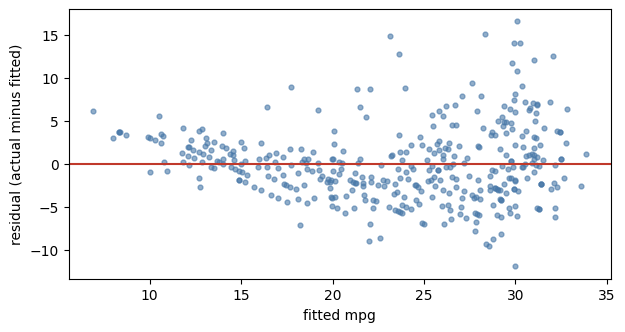

R-squared   : 0.693
residual SD : 4.33 mpg


In [5]:
plt.scatter(fit.fittedvalues, fit.resid, s=12, alpha=0.6, color="#4878a8")
plt.axhline(0, color="#c0392b", lw=1.5)
plt.xlabel("fitted mpg"); plt.ylabel("residual (actual minus fitted)"); plt.show()

print(f"R-squared   : {fit.rsquared:.3f}")
print(f"residual SD : {np.sqrt(fit.scale):.2f} mpg")

The residuals bend: they sit above zero at both ends and below it in the middle, so the line under-predicts the lightest and heaviest cars. That is a straight line fitted to a relationship that curves. The residual SD says a typical car sits about that many mpg off the line, which is the number to quote when someone asks how good the model is.

## 5. A 0/1 predictor is a two-group comparison

Regression on a dummy variable reproduces the two-sample t-test exactly.

In [6]:
cars["is_american"] = (cars["origin"] == "American").astype(int)
d = smf.ols("mpg ~ is_american", data=cars).fit()

amer = cars.loc[cars.is_american == 1, "mpg"]
other = cars.loc[cars.is_american == 0, "mpg"]

print(f"intercept (mean of the 0 group)  : {d.params['Intercept']:.3f}")
print(f"actual mean of the 0 group       : {other.mean():.3f}")
print(f"dummy coefficient (difference)   : {d.params['is_american']:.3f}")
print(f"actual difference in means       : {amer.mean() - other.mean():.3f}")
print(f"\nregression t        : {d.tvalues['is_american']:.3f}")
print(f"pooled two-sample t : {stats.ttest_ind(amer, other, equal_var=True).statistic:.3f}")

intercept (mean of the 0 group)  : 29.133
actual mean of the 0 group       : 29.133
dummy coefficient (difference)   : -9.100
actual difference in means       : -9.100

regression t        : -13.529
pooled two-sample t : -13.529


Same estimate, same standard error, same $p$-value. The two-group comparison from Unit 1 is a regression with one 0/1 predictor.

## 6. A category with more than two levels

One level becomes the baseline and every other coefficient is read against it.

In [7]:
m = smf.ols("mpg ~ C(origin)", data=cars).fit()
print(m.params.round(2), "\n")
print("baseline is the level that is missing from that list:",
      sorted(cars.origin.unique())[0])
print(cars.groupby("origin").mpg.mean().round(2))

Intercept                20.03
C(origin)[T.European]     7.57
C(origin)[T.Japanese]    10.42
dtype: float64 

baseline is the level that is missing from that list: American
origin
American    20.03
European    27.60
Japanese    30.45
Name: mpg, dtype: float64


Each coefficient is that origin versus the baseline, not versus zero and not versus the other levels. Add the baseline mean to a coefficient and you get that group's mean.

## 7. When the slope itself differs by group: an interaction



In [8]:
inter = smf.ols("mpg ~ weight * is_american", data=cars).fit()
print(inter.params.round(6), "\n")

b_w = inter.params["weight"]
b_wa = inter.params["weight:is_american"]
print(f"slope for non-American cars : {1000*b_w:.2f} mpg per 1000 lb")
print(f"slope for American cars     : {1000*(b_w + b_wa):.2f} mpg per 1000 lb")
print(f"p-value on the interaction  : {inter.pvalues['weight:is_american']:.3f}")

Intercept             48.771246
weight                -0.008467
is_american           -5.622778
weight:is_american     0.001613
dtype: float64 

slope for non-American cars : -8.47 mpg per 1000 lb
slope for American cars     : -6.85 mpg per 1000 lb
p-value on the interaction  : 0.077


With the interaction in the model, the coefficient on `weight` is the slope for the group coded 0, not an overall slope. The interaction term is the gap between the two slopes.

## 8. A coefficient changes when another variable joins it

First in a made-up world where we know the answer, then in the real data.

In [9]:
n = 3000
z = rng.normal(0, 1, n)                    # the lurking variable
x = 0.8*z + rng.normal(0, 0.6, n)          # x is driven by z
y = 2.0*z + rng.normal(0, 1.0, n)          # y is driven by z, NOT by x
sim = pd.DataFrame({"x": x, "y": y, "z": z})

naive = smf.ols("y ~ x", data=sim).fit()
adjusted = smf.ols("y ~ x + z", data=sim).fit()
print(f"true effect of x on y         : 0.000")
print(f"slope on x, z left out        : {naive.params['x']:.3f}  (t = {naive.tvalues['x']:.1f})")
print(f"slope on x, z included        : {adjusted.params['x']:.3f}  (t = {adjusted.tvalues['x']:.1f})")

true effect of x on y         : 0.000
slope on x, z left out        : 1.579  (t = 54.2)
slope on x, z included        : -0.006  (t = -0.2)


The naive regression reports a large, overwhelmingly significant effect of something that does nothing. More rows would only make the $t$-statistic bigger. Including $z$ is what fixes it, and in real work you have to know to look for $z$.

In [10]:
raw = smf.ols("mpg ~ acceleration", data=cars).fit()
adj = smf.ols("mpg ~ acceleration + weight", data=cars).fit()

print(f"slope on acceleration, alone          : {raw.params['acceleration']:+.3f} mpg per second")
print(f"slope on acceleration, with weight    : {adj.params['acceleration']:+.3f} mpg per second")
print(f"share of the raw association left     : "
      f"{100*adj.params['acceleration']/raw.params['acceleration']:.0f}%")
print(f"\ncorr(acceleration, weight) = {cars.acceleration.corr(cars.weight):+.2f}")

slope on acceleration, alone          : +1.198 mpg per second
slope on acceleration, with weight    : +0.262 mpg per second
share of the raw association left     : 22%

corr(acceleration, weight) = -0.42


Heavy cars are both slow to accelerate and thirsty, so most of the raw relationship was weight under another name. This does not show that acceleration has no effect. It shows that the raw number was mostly something else.

## 9. Significant is not the same as useful



In [11]:
print(f"p-value on acceleration : {raw.pvalues['acceleration']:.2e}")
print(f"R-squared               : {raw.rsquared:.3f}")
print(f"residual SD             : {np.sqrt(raw.scale):.2f} mpg")

p-value on acceleration : 1.78e-18
R-squared               : 0.179
residual SD             : 7.08 mpg


Overwhelmingly significant, and it explains under a fifth of the variation. The $p$-value, the slope, and $R^2$ answer three different questions.